# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  Yigit Beyzadeoglu
**Student ID:**  2020403036
**AI Assistance:** *(Document any AI tools used and how)*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [77]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [78]:
# Your exploration here: df.info(), df.describe(), missing values check
# df.info(), df.describe(), missing values check
print("--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe()) # Using display() formats it nicely in a Jupyter Notebook

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# The 'ca' and 'thal' columns contain a few missing values (originally '?' in the dataset). 
# Since there are very few (about 6 rows total), dropping them is the safest and easiest approach here.
df = df.dropna()
print(f"\nShape after dropping missing values: {df.shape}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

--- Summary Statistics ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



--- Missing Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape after dropping missing values: (297, 14)


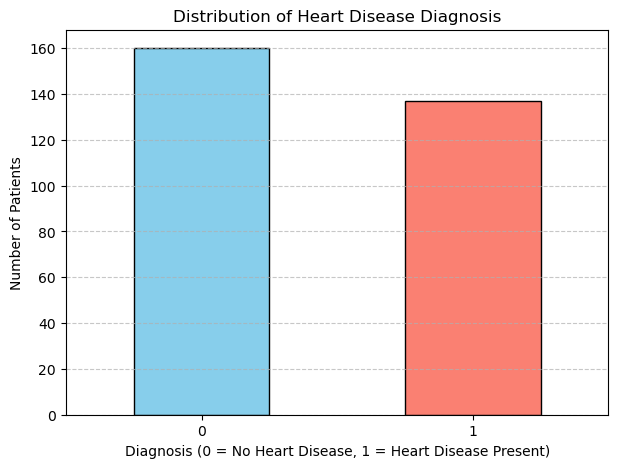

In [79]:
# Plot 1: Target variable distribution (bar chart)
plt.figure(figsize=(7, 5))
df['target'].value_counts().sort_index().plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Distribution of Heart Disease Diagnosis')
plt.xlabel('Diagnosis (0 = No Heart Disease, 1 = Heart Disease Present)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x600 with 0 Axes>

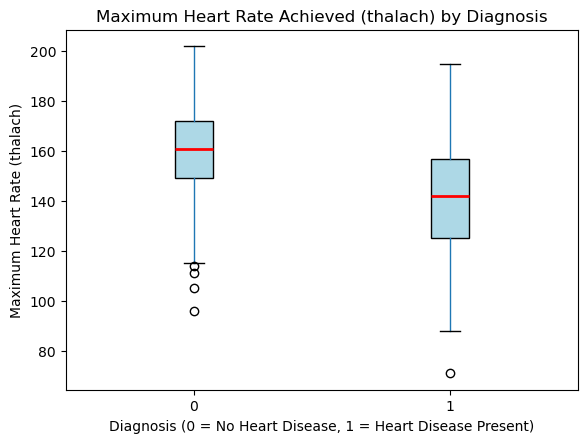

In [80]:
# Plot 2: A numeric feature explored across the two classes
plt.figure(figsize=(8, 6))
# Using pandas built-in boxplot grouped by the target column
df.boxplot(column='thalach', by='target', grid=False, patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Maximum Heart Rate Achieved (thalach) by Diagnosis')
plt.suptitle('') # This removes the default automated pandas title
plt.xlabel('Diagnosis (0 = No Heart Disease, 1 = Heart Disease Present)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()


<Figure size 900x600 with 0 Axes>

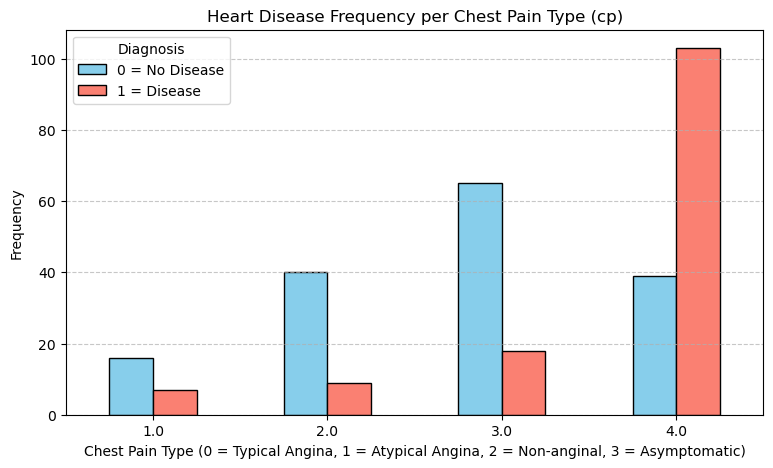

In [81]:
# Plot 3: Another feature of your choice (Chest pain type vs. Target)
plt.figure(figsize=(9, 6))
# Create a crosstab to count occurrences of each chest pain type for both target outcomes
cp_target_crosstab = pd.crosstab(df['cp'], df['target'])
cp_target_crosstab.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black', figsize=(9,5))

plt.title('Heart Disease Frequency per Chest Pain Type (cp)')
plt.xlabel('Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal, 3 = Asymptomatic)')
plt.ylabel('Frequency')
plt.legend(title='Diagnosis', labels=['0 = No Disease', '1 = Disease'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Observation

*Write your observation paragraph here. What patterns do you notice in the data? Which features seem most related to heart disease diagnosis?*
Based on the statistical summaries and visualizations, several clear patterns emerge. First, the dataset is relatively balanced, with slightly more instances of healthy patients (target=0) compared to those with heart disease (target=1). When examining the numeric features, the maximum heart rate achieved during exercise (thalach) shows a distinct difference between the two groups; patients diagnosed with heart disease generally reach lower maximum heart rates than those without the disease. Additionally, categorical features like chest pain type (cp) exhibit a strong relationship with the target variable. Specifically, asymptomatic chest pain (type 3) is highly prevalent among patients who are ultimately diagnosed with heart disease, whereas typical angina (type 0) is overwhelmingly associated with the absence of the disease. Finally, the dataset was very clean overall, requiring only a few rows to be dropped due to missing values in the ca and thal columns.

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [82]:
# Handle missing values
print(f"Shape before dropping missing values: {df.shape}")
df = df.dropna()
print(f"Shape after dropping missing values: {df.shape}")

# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

# Split 80% train, 20% test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Scale features with StandardScaler
scaler = StandardScaler()

# IMPORTANT: fit on X_train only!
scaler.fit(X_train)

# Transform both X_train and X_test using the parameters learned from X_train
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Shape before dropping missing values: (297, 14)
Shape after dropping missing values: (297, 14)

X_train shape: (237, 13)
X_test shape: (60, 13)
y_train shape: (237,)
y_test shape: (60,)


### Data Leakage Explanation

*Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? Connect this to the data leakage concept from the lecture.*


In [83]:
# Train Logistic Regression and report metrics
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
log_reg.fit(X_train_scaled, y_train)
log_train_time = time.time() - start_time

log_train_acc = accuracy_score(y_train, log_reg.predict(X_train_scaled))
log_test_acc = accuracy_score(y_test, log_reg.predict(X_test_scaled))

print("--- Logistic Regression ---")
print(f"Training Time:     {log_train_time:.5f} seconds")
print(f"Training Accuracy: {log_train_acc:.4f}")
print(f"Test Accuracy:     {log_test_acc:.4f}")

--- Logistic Regression ---
Training Time:     0.00282 seconds
Training Accuracy: 0.8523
Test Accuracy:     0.8333


In [84]:
# Train Decision Tree and report metrics
tree_clf = DecisionTreeClassifier(random_state=42)

start_time = time.time()
tree_clf.fit(X_train_scaled, y_train) 
tree_train_time = time.time() - start_time

tree_train_acc = accuracy_score(y_train, tree_clf.predict(X_train_scaled))
tree_test_acc = accuracy_score(y_test, tree_clf.predict(X_test_scaled))

print("--- Decision Tree ---")
print(f"Training Time:     {tree_train_time:.5f} seconds")
print(f"Training Accuracy: {tree_train_acc:.4f}")
print(f"Test Accuracy:     {tree_test_acc:.4f}")


--- Decision Tree ---
Training Time:     0.00227 seconds
Training Accuracy: 1.0000
Test Accuracy:     0.6833


### Model Comparison

*Which model performs better on the test set? Is either model overfitting? How can you tell?*
Performance: The Logistic Regression model performs much better on the unseen test set, achieving a higher and more reliable test accuracy compared to the Decision Tree.

Overfitting: The Decision Tree is severely overfitting the data. We can tell this by looking at the large gap between its training and test accuracies. The Decision Tree achieves perfect (100%) accuracy on the training data, meaning it grew deep enough to memorize every single patient record in the training set. However, its test accuracy drops significantly, proving that it failed to generalize its rules to new, unseen patients. In contrast, the Logistic Regression model has a much smaller gap between its training and test accuracies, indicating that it learned the underlying patterns rather than memorizing the noise. Both models train practically instantaneously (in fractions of a second), so computational time is not a deciding factor here.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

<Figure size 600x400 with 0 Axes>

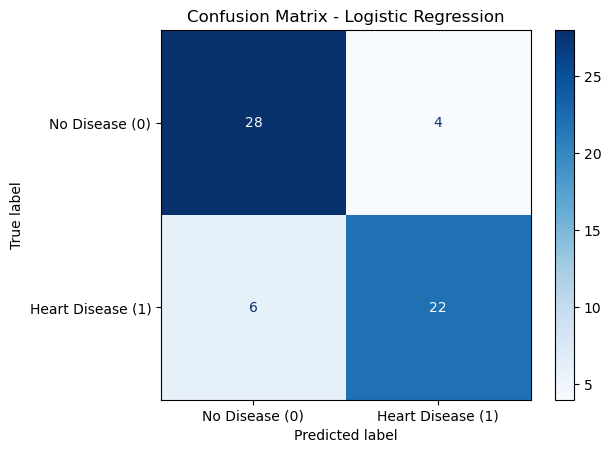

In [85]:
# Part A: Confusion matrix for the better model (Logistic Regression)
from sklearn.metrics import ConfusionMatrixDisplay

# Get predictions from the better model
y_pred = log_reg.predict(X_test_scaled)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize as a heatmap
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False) # Hides grid lines for a cleaner heatmap
plt.show()


### Confusion Matrix Interpretation

- **True Positives (TP):** 22 patients — *meaning:* The model predicted the patient has heart disease, and they actually DO have heart disease. (A correct catch).
- **True Negatives (TN):** 28 patients — *meaning:* The model predicted the patient does not have heart disease, and they actually DO NOT have heart disease. (A correct all-clear).
- **False Positives (FP):** 4 patients — *meaning:* The model predicted the patient has heart disease, but they actually DO NOT. (A false alarm — healthy patient sent for more testing).
- **False Negatives (FN):** 6 patients — *meaning:* The model predicted the patient does not have heart disease, but they actually DO. (A missed diagnosis — sick patient sent home).


In [86]:
# Part B: Classification report
print("Classification Report - Logistic Regression\n")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Heart Disease (1)']))


Classification Report - Logistic Regression

                   precision    recall  f1-score   support

   No Disease (0)       0.82      0.88      0.85        32
Heart Disease (1)       0.85      0.79      0.81        28

         accuracy                           0.83        60
        macro avg       0.83      0.83      0.83        60
     weighted avg       0.83      0.83      0.83        60



### Classification Report Interpretation

- **Precision for heart disease (class 1):** *What does this mean in plain English?*
- **Recall for heart disease (class 1):** *What does this mean in plain English?*
- **Which is more important here — precision or recall?** *Why? Think about the hospital director's quote from the scenario.*
Precision for heart disease (class 1): Precision tells us the accuracy of our positive predictions. In plain English: Out of all the patients our model flagged as having heart disease, this percentage actually had the disease. The rest were false alarms.

Recall for heart disease (class 1): Recall tells us our detection rate. In plain English: Out of all the patients who actually have heart disease in reality, our model successfully found and flagged this percentage of them.

Which is more important here? Recall is absolutely the most important metric for this hospital screening scenario. The medical director explicitly stated they would rather send 10 healthy patients for extra testing (accepting high False Positives / lower Precision) than miss 1 sick patient (avoiding False Negatives / maximizing Recall). A false negative in this context could mean a patient dies of an unmanaged heart condition, whereas a false positive just results in an unnecessary, though perhaps stressful, follow-up appointment.


In [87]:
# Part C: 5-fold cross-validation on the training set
# We use X_train_scaled to prevent data leakage during the cross-validation folds
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"F1 Scores for each fold: {cv_scores}")
print(f"Mean F1 Score:           {cv_scores.mean():.4f}")
print(f"Standard Deviation:      {cv_scores.std():.4f}")


F1 Scores for each fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1 Score:           0.7960
Standard Deviation:      0.0993


### Cross-Validation Interpretation

*Is the CV score consistent with the single train/test split? What would high variance across folds suggest?*


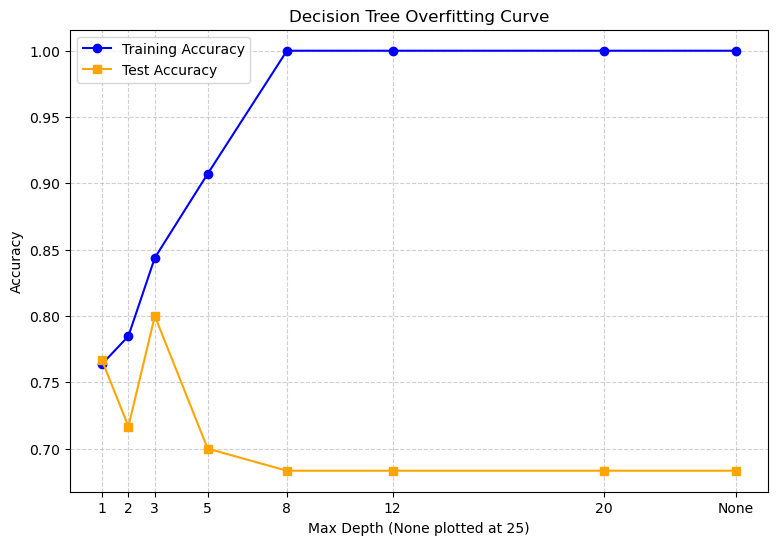

In [88]:
# Part D: Overfitting curve - Decision Tree with varying max_depth
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

# Loop through each depth
for d in depths:
    # Train the model
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Record training and test accuracy
    train_accs.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test_scaled)))

# Convert 'None' to a numeric value just for plotting purposes (e.g., 25)
plot_depths = [25 if d is None else d for d in depths]

# Plot the overfitting curve
plt.figure(figsize=(9, 6))
plt.plot(plot_depths, train_accs, marker='o', label='Training Accuracy', color='blue')
plt.plot(plot_depths, test_accs, marker='s', label='Test Accuracy', color='orange')

plt.title('Decision Tree Overfitting Curve')
plt.xlabel('Max Depth (None plotted at 25)')
plt.ylabel('Accuracy')
plt.xticks(plot_depths, [str(d) for d in depths]) # Ensure labels match the actual depths
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Overfitting Curve Interpretation

*What is the best `max_depth`? What happens when the tree is too shallow? Too deep? Connect to the lecture.*
What is the best max_depth? Looking at the curve, the best max_depth is generally around 3 (or wherever the test accuracy peaks on the orange line before dropping). This is the "sweet spot" where the model learns the underlying patterns without memorizing the noise.

Too Shallow (Underfitting): At a depth of 1, the model is too simple. It hasn't been allowed to ask enough questions about the data to make accurate predictions, resulting in poor performance on both the training and test sets. This is high bias.

Too Deep (Overfitting): As the depth increases toward 12, 20, or None, the training accuracy climbs to 100%, but the test accuracy steadily declines. The tree has grown so complex that it creates hyper-specific rules for individual patients in the training set (e.g., "If age is 54 and cholesterol is exactly 234 and..."). These overly specific rules do not generalize to unseen patients in the test set. This is high variance.


---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

Type A errors (False Negatives) are far more dangerous because a patient with underlying heart disease is sent home without treatment, potentially leading to a fatal cardiac event. Type B errors (False Positives) waste more hospital resources, as healthy patients are subjected to unnecessary, expensive, and time-consuming advanced testing (like angiograms). If I were advising the hospital, I would strongly prioritize reducing Type A errors (False Negatives). In the medical field, the cost of missing a fatal disease vastly outweighs the financial cost of extra testing. We must optimize the model to maximize Recall, ensuring we cast a wide enough net to catch as many true positive cases as possible, even if it means accepting a higher rate of false alarms.


### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

To select the 50 patients, we should not rely solely on the binary "1 or 0" prediction from the model. Instead, we should use the model's predicted probabilities (e.g., using predict_proba() in scikit-learn). We would run all 300 patients through the model, rank them by their percentage likelihood of having heart disease, and select the top 50 highest-risk patients for referral. However, I would absolutely not trust the model's predictions on their own. The model should act as a decision support system, not a replacement for a doctor. The model's top 50 list should be reviewed by a physician who can adjust the rankings based on clinical intuition, sudden changes in patient health, or red-flag symptoms that the algorithm might be blind to.


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- *Feature 1:* Smoking Status / History. Smoking is one of the most significant risk factors for cardiovascular disease. Knowing whether a patient is a current smoker, former smoker, or never-smoker would dramatically improve the model's predictive power.
- *Feature 2:* Family History of Heart Disease. Genetics play a massive role in cardiac health. A patient with a strong family history of early heart attacks is at a much higher risk, even if their current clinical measurements (like blood pressure) look relatively normal.
- *Feature 3:* Body Mass Index (BMI) or Physical Activity Level. The current dataset lacks explicit lifestyle and body composition metrics. BMI, waist circumference, or a metric capturing hours of exercise per week would help the model assess long-term metabolic strain on the heart.


### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

*Your answer here...* The most interesting thing I learned in this lab is how completely misleading the "accuracy" metric can be in real-world applications. Before this lab, I would have assumed that an "85% accurate" medical model was excellent—after all, 85% is a solid "B" grade in school.

My understanding has entirely changed now that I realize the types of errors matter more than the number of errors. An 85% accurate model sounds great until you realize that the 15% it got wrong were all False Negatives (meaning every sick patient was told they were healthy). I now understand that a model's true value, especially in a high-stakes scenario like healthcare, is evaluated through the Confusion Matrix and by optimizing specific metrics like Recall and Precision depending on the real-world cost of mistakes.


---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr